# Notebook showing Stage control through autoscript

### Quick Start Code Cell

In [1]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 11000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"test/{d}/1") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("test/microscope/1"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...
Project dir: /Users/austin/Documents/GitHub/asyncroscopy
Starting Tango Database...
  Waiting for database.... ✅ ready
Registering devices...
Connected: stingray-zm68g.device.utk.edu:11000

  registered: test/scan/1
  registered: test/eds/1
  registered: test/stage/1
  registered: test/microscope/1
  property:   scan_device_address = test/scan/1
  property:   eds_device_address = test/eds/1
  property:   stage_device_address = test/stage/1

Done!
Starting device servers...
  Waiting for test/stage/1.... ✅ ready (1.0s)
  Waiting for test/scan/1... ✅ ready (0.0s)
  Waiting for test/eds/1... ✅ ready (0.0s)
Starting Microscope...
  Waiting for test/microscope/1.... ✅ ready (1.0s)

✅ All servers ready!


## 1. Connect to devices

In [3]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:11000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"


# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/eds/1
test/haadf/1
test/microscope/1
test/scan/1
test/stage/1


In [4]:
scan = tango.DeviceProxy("test/scan/1")
microscope_proxy = tango.DeviceProxy("test/microscope/1")

scan.set_timeout_millis(120_000)
microscope_proxy.set_timeout_millis(120_000)

In [5]:
print('Microscope state:', microscope_proxy.state())


Microscope state: ON


In [6]:
scan.Activate(['haadf'])
scan.dwell_time   = 600e-6  # µs
scan.imsize  = 8

print('dwell_time  :', scan.dwell_time)
print('image size :', scan.imsize)


dwell_time  : 0.0006
image size : 8


In [7]:
# fov cutoff is 0.52e-9
fov = 0.52e-9
microscope_proxy.set_fov(fov)

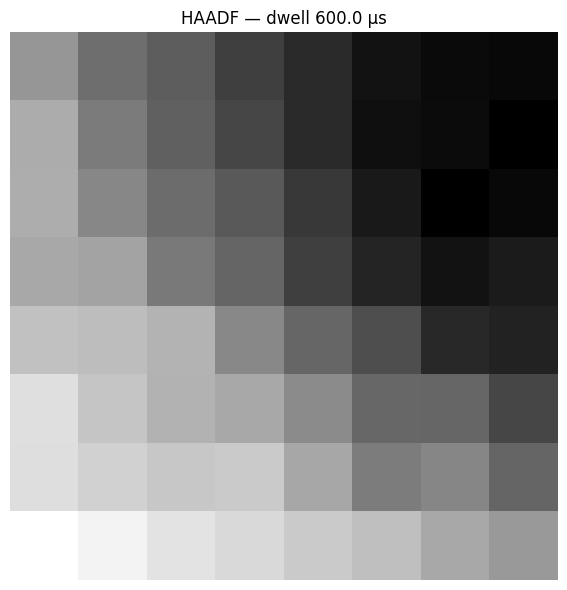

In [8]:
# get_image returns DevEncoded = (json_metadata_str, raw_bytes)
json_meta, raw_bytes = microscope_proxy.get_scanned_image()

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap='gray', interpolation='none')
ax.set_title(f"HAADF — dwell {metadata['dwell_time']*1e6:.1f} µs")
ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
# get the stage
starting_position = microscope_proxy.get_stage()
print('Stage position:', starting_position)


Stage position: [ 1.00153215e-04 -1.49816900e-04 -9.59366298e-05  9.90679982e-05]


In [85]:
# move the stage
move_by = -100e-6  # 10 µm

new_position = starting_position + np.array([move_by, 0, 0, 1])

In [86]:
microscope_proxy.move_stage(new_position)

In [87]:
microscope_proxy.move_stage(starting_position)